# Preprocessing — chuẩn hoá dữ liệu Uber NYC cho DBSCAN

Notebook này **không chứa logic preprocessing** — tất cả nằm trong `src/preprocess.py`.
Mục đích của notebook là minh bạch **từng bước xử lý**: dữ liệu thô → dữ liệu sẵn sàng chạy clustering, kèm số liệu đếm và kiểm chứng.

> Notebook clustering sau sẽ `import` lại đúng module này, không copy-paste gì cả.

## Trình tự xử lý

```
data/raw/*.csv (6 tháng, 4.53M chuyến)
        │  1. load_raw         đổi tên cột, parse thời gian, dtype float64
        │  2. add_time_features  hour, dow, date, is_peak...
        │  3. clean_coordinates loại toạ độ lỗi (thiếu / (0,0) / ngoài NYC)
        │  4. to_metric        chiếu sang toạ độ phẳng ĐƠN VỊ MÉT + kiểm chứng
        ▼
  5. filter_window    cắt khung giờ × ngày trong tuần × vùng
        │  6. sample_points  lấy mẫu ngẫu nhiên có seed cố định
        ▼
data/processed/<ca>.csv  +  outputs/preprocess_report.json
```

## 4 nguyên tắc bắt buộc

| Nguyên tắc | Vì sao |
|---|---|
| **Không z-score lat/lon** | Chuẩn hoá phá vỡ ranh giới không gian, cụm không còn bám đường phố |
| **Tính mọi khoảng cách trong hệ phẳng đơn vị mét** | Euclid trên độ là sai (1° lon dài hơn 1° lat ở NYC ~1.3 lần) |
| **Cắt khung giờ × ngày** | Vận hành thực tế khác nhau giữa 8h sáng và 6h tối, gộp cả ngày sẽ trộn hai hiện tượng |
| **Chốt tham số bằng k-distance** | `eps` và `MinPts` phải suy ra từ dữ liệu, không chọn tùy ý |

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# jupyter chay voi cwd = thu muc notebook, nen phai them thu muc goc vao sys.path
ROOT = Path.cwd()
while not (ROOT / "src" / "preprocess.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "src" / "preprocess.py").exists():
    raise FileNotFoundError("Khong tim thay src/preprocess.py")
sys.path.insert(0, str(ROOT / "src"))  # module nam trong thu muc src/

import preprocess as pp

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["figure.figsize"] = (12, 7)

DATA_RAW = ROOT / "data" / "raw"
DATA_PROC = ROOT / "data" / "processed"
OUT = ROOT / "outputs"
OUT.mkdir(exist_ok=True)

print("src/preprocess.py:", pp.__file__)
print("Cac kich ban:", sorted(pp.SCENARIOS))

src/preprocess.py: /Users/hongphuc/workspace/CS313/Density-based Method/src/preprocess.py
Cac kich ban: ['ca_diem_t7_manhattan', 'ca_diem_t7_toan_bo', 'ca_sang_t2_manhattan', 'dem_thu7_manhattan']


---

## 1. Đọc dữ liệu + lọc toạ độ lỗi (bước dùng chung)

`prepare_raw` gộp 3 bước đầu và chỉ chạy **một lần** cho mọi kịch bản.

In [2]:
clean, shared_report = pp.prepare_raw(DATA_RAW)

shared_report

  doc apr14.csv       564,516 dong


  doc aug14.csv       829,275 dong


  doc jul14.csv       796,121 dong


  doc jun14.csv       663,844 dong


  doc may14.csv       652,435 dong


  doc sep14.csv     1,028,136 dong


  loc toa do: 4,534,327 -> 4,502,417


{'raw': {'dong': 4534327, 'files': ['*14.csv']},
 'toi_buoc_loc_toa_do': {'vao': 4534327,
  'ra': 4502417,
  'thieu_toa_do': 0,
  'toa_do_0_0': 0,
  'ngoai_bien_gioi': 31910,
  'bi_loai_tong': 31910}}

In [3]:
qc = shared_report["toi_buoc_loc_toa_do"]

qc_tbl = pd.DataFrame(
    [
        {"buoc": "vao", "so_dong": qc["vao"]},
        {"buoc": "- thieu toa do", "so_dong": -qc["thieu_toa_do"]},
        {"buoc": "- toa do (0, 0)", "so_dong": -qc["toa_do_0_0"]},
        {"buoc": "- ngoai bien gioi NYC", "so_dong": -qc["ngoai_bien_gioi"]},
        {"buoc": "ra", "so_dong": qc["ra"]},
    ]
)
qc_tbl["ty_le_so_vao_pct"] = (qc_tbl["so_dong"] / qc["vao"] * 100).round(3)
print(qc_tbl)
print()
print(f"Loai {qc['bi_loai_tong']:,} dong ({qc['bi_loai_tong'] / qc['vao'] * 100:.3f}%)")

                    buoc  so_dong  ty_le_so_vao_pct
0                    vao  4534327           100.000
1         - thieu toa do        0             0.000
2        - toa do (0, 0)        0             0.000
3  - ngoai bien gioi NYC   -31910            -0.704
4                     ra  4502417            99.296

Loai 31,910 dong (0.704%)


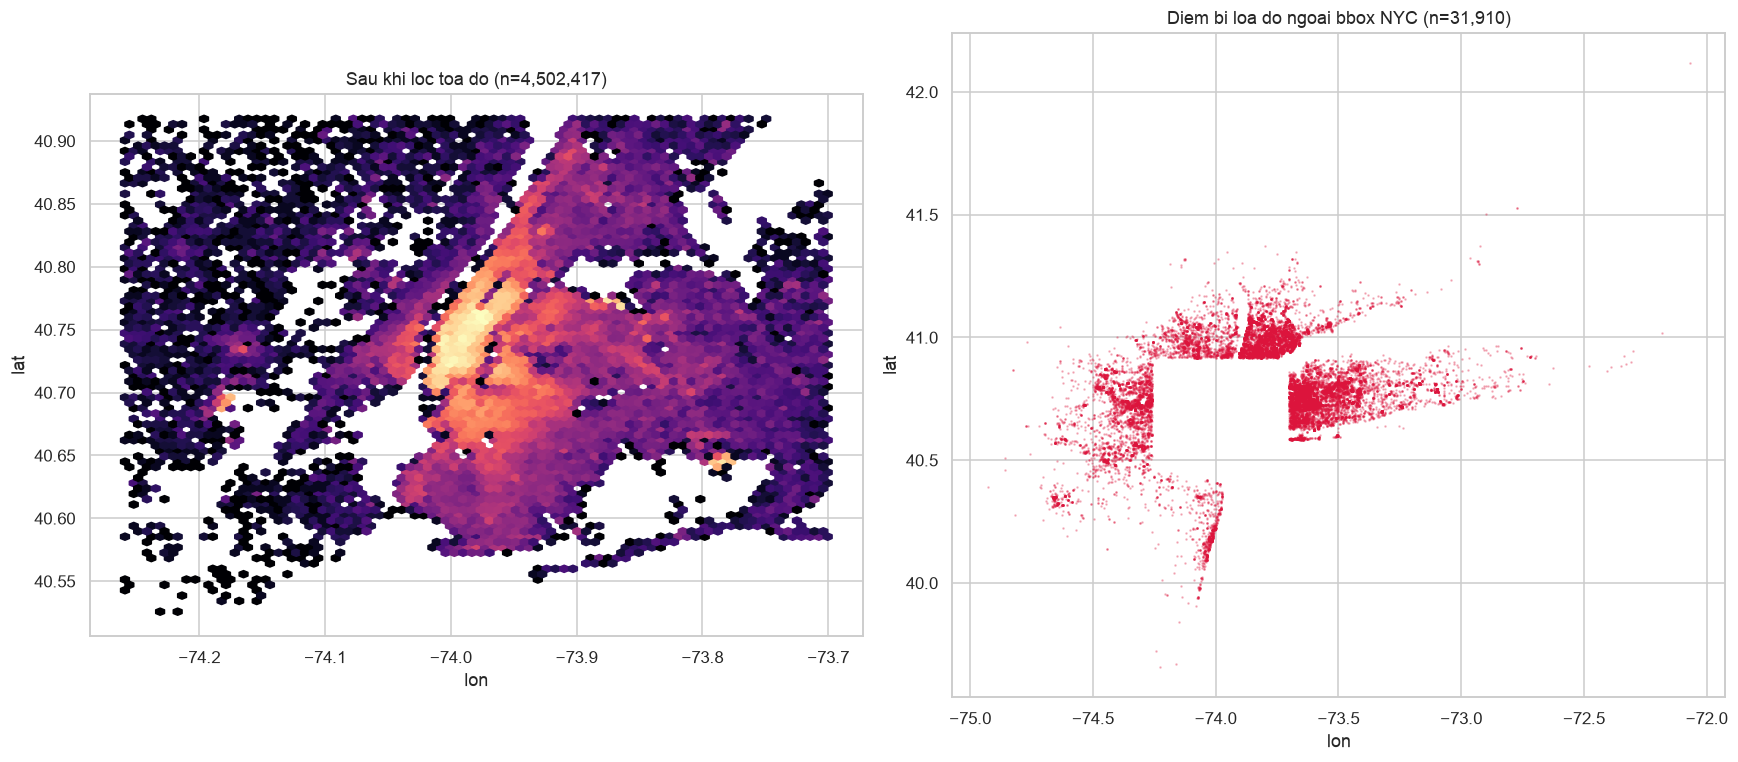

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

axes[0].hexbin(clean["lon"], clean["lat"], gridsize=80, cmap="magma", mincnt=1, bins="log")
axes[0].set_title(f"Sau khi loc toa do (n={len(clean):,})")

# Ve lai phan bi gioi cua thanh pho de thay vung bi loa nam o dau
raw_spot = pd.concat(
    [
        pd.read_csv(p, usecols=["Lat", "Lon"]) for p in sorted(DATA_RAW.glob("*14.csv"))
    ],
    ignore_index=True,
)
bad = raw_spot[
    ~(
        raw_spot["Lat"].between(*[pp.NYC_BBOX[0], pp.NYC_BBOX[2]])
        & raw_spot["Lon"].between(*[pp.NYC_BBOX[1], pp.NYC_BBOX[3]])
    )
]
axes[1].scatter(bad["Lon"], bad["Lat"], s=0.4, alpha=0.3, color="crimson")
axes[1].set_title(f"Diem bi loa do ngoai bbox NYC (n={len(bad):,})")

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("lon")
    ax.set_ylabel("lat")

plt.tight_layout()
plt.savefig(OUT / "prep_01_cleaning.png", bbox_inches="tight")
plt.show()

> **Bài học:** toạ độ sai không nằm rải rác ngẫu nhiên mênh mông — chúng tụ lại thành các cụm rõ rệt.
> Nếu không lọc, DBSCAN sẽ phát hiện "hotspot" ở New Jersey hoặc ngoài biển, và mọi phân tích phía sau đều vô nghĩa.

---

## 2. Chiếu sang toạ độ phẳng đơn vị mét

Đây là bước quyết định `eps` có nghĩa hay không. Đo thử cả 3 phương án:

In [5]:
lat, lon = clean["lat"].to_numpy(), clean["lon"].to_numpy()
lat0, lon0 = float(lat.mean()), float(lon.mean())
R = pp.EARTH_R


def eq_cos_lat0():
    return np.column_stack(
        [R * np.radians(lon - lon0) * np.cos(np.radians(lat0)), R * np.radians(lat - lat0)]
    )


def eq_cos_lat():
    return np.column_stack(
        [R * np.radians(lon - lon0) * np.cos(np.radians(lat)), R * np.radians(lat - lat0)]
    )


rng = np.random.default_rng(42)
n = len(clean)
i, j = rng.integers(0, n, 20000), rng.integers(0, n, 20000)
d_true = pp.haversine_m(lat[i], lon[i], lat[j], lon[j])

rows = []
for name, fn in [
    ("equirectangular cos(lat0)", eq_cos_lat0),
    ("equirectangular cos(lat)", eq_cos_lat),
    ("azimuthal equidistant", lambda: pp.to_metric(lat, lon, lat0, lon0)),
]:
    xy = fn()
    d = np.hypot(xy[i, 0] - xy[j, 0], xy[i, 1] - xy[j, 1])
    far = d_true >= 100  # thu do cua bai la 100 m
    rel = np.abs(d[far] - d_true[far]) / d_true[far]
    rows.append(
        {
            "phuong_phap": name,
            "sai_so_tb_pct": rel.mean() * 100,
            "sai_so_p99_pct": np.percentile(rel, 99) * 100,
            "sai_so_max_pct": rel.max() * 100,
        }
    )

pd.DataFrame(rows).round(6)

,phuong_phap,sai_so_tb_pct,sai_so_p99_pct,sai_so_max_pct
0,equirectangular cos(lat0),0.012395,0.077516,0.189823
1,equirectangular cos(lat),0.008395,0.055439,0.116014
2,azimuthal equidistant,0.000002,0.000019,0.000124


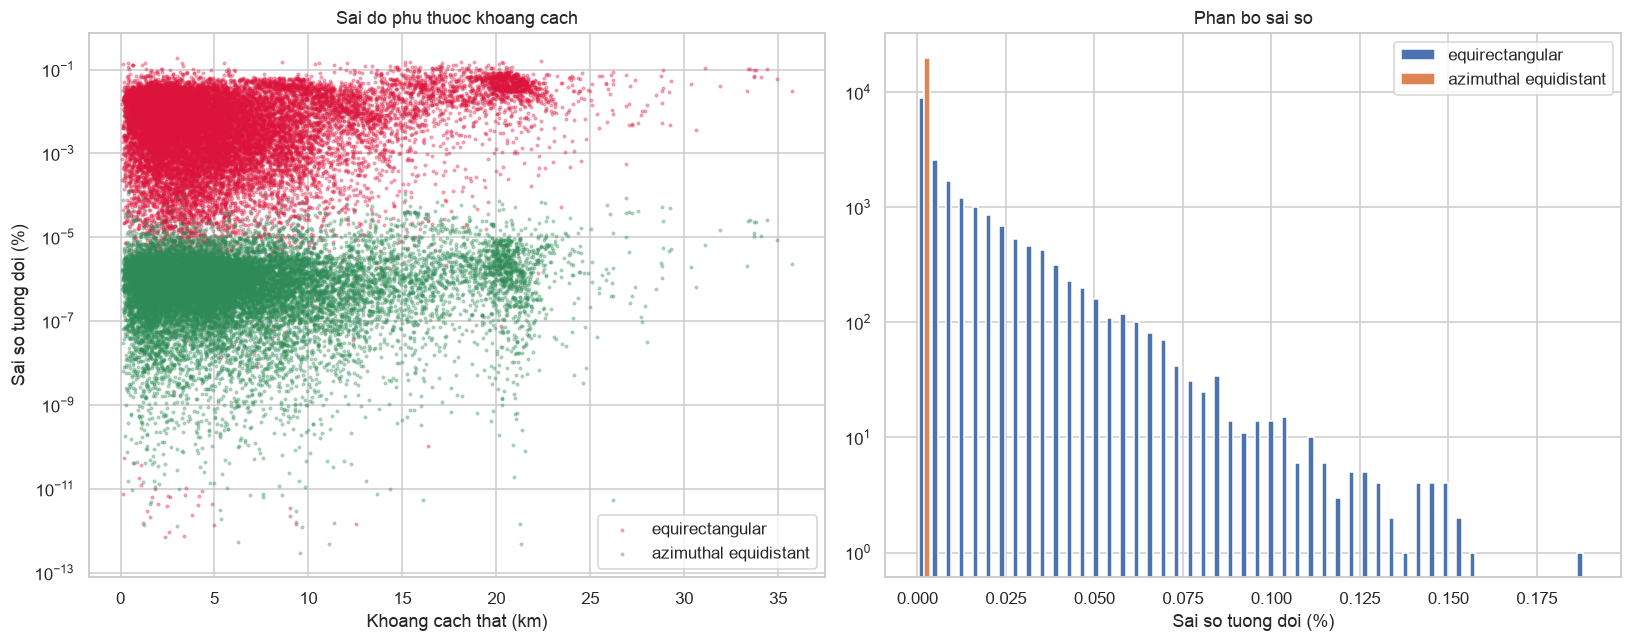

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

xy_eq = eq_cos_lat0()
xy_ae = pp.to_metric(lat, lon, lat0, lon0)
far = d_true >= 100

for xy, name, color in [(xy_eq, "equirectangular", "crimson"), (xy_ae, "azimuthal equidistant", "seagreen")]:
    d = np.hypot(xy[i, 0] - xy[j, 0], xy[i, 1] - xy[j, 1])
    rel = np.abs(d[far] - d_true[far]) / d_true[far] * 100
    axes[0].scatter(d_true[far] / 1000, rel, s=3, alpha=0.3, label=name, color=color)

axes[0].set_yscale("log")
axes[0].set_xlabel("Khoang cach that (km)")
axes[0].set_ylabel("Sai so tuong doi (%)")
axes[0].set_title("Sai do phu thuoc khoang cach")
axes[0].legend()

axes[1].hist(
    [
        np.abs(
            np.hypot(xy_eq[i, 0] - xy_eq[j, 0], xy_eq[i, 1] - xy_eq[j, 1])[far] - d_true[far]
        )
        / d_true[far]
        * 100,
        np.abs(
            np.hypot(xy_ae[i, 0] - xy_ae[j, 0], xy_ae[i, 1] - xy_ae[j, 1])[far] - d_true[far]
        )
        / d_true[far]
        * 100,
    ],
    bins=50,
    log=True,
    label=["equirectangular", "azimuthal equidistant"],
)
axes[1].set_xlabel("Sai so tuong doi (%)")
axes[1].set_title("Phan bo sai so")
axes[1].legend()

plt.tight_layout()
plt.savefig(OUT / "prep_02_projection.png", bbox_inches="tight")
plt.show()

Kết luận: chỉ **azimuthal equidistant** đạt sai số < 0.001% trên toàn bộ NYC, nên `eps` đọc được là **mét thật** mà không phải hiệu chỉnh tay.

---

## 3. Cắt khung giờ × ngày × vùng — 4 kịch bản

Dùng `build_all` để cả 4 ca dùng chung dữ liệu đã đọc một lần.

In [7]:
reports: dict = {}
results = pp.build_all(list(pp.SCENARIOS.values()), DATA_RAW, report=reports)
print()
print(f"Da xu ly {len(results)} kich ban")

  doc apr14.csv       564,516 dong


  doc aug14.csv       829,275 dong


  doc jul14.csv       796,121 dong


  doc jun14.csv       663,844 dong


  doc may14.csv       652,435 dong


  doc sep14.csv     1,028,136 dong


  loc toa do: 4,534,327 -> 4,502,417

=== ca_diem_t7_manhattan: Thu Bay 17:00-19:00 ===
  -> 78,066 diem | phieu toi da 0.000020%

=== ca_diem_t7_toan_bo: Thu Bay 17:00-19:00 ===
  -> 87,810 diem | phieu toi da 0.000118%

=== ca_sang_t2_manhattan: Thu Hai 08:00-10:00 ===
  -> 43,781 diem | phieu toi da 0.000039%

=== dem_thu7_manhattan: Thu Bay 00:00-04:00 ===


  -> 62,900 diem | phieu toi da 0.000030%

Da xu ly 4 kich ban


In [8]:
def flow_table(name: str) -> pd.DataFrame:
    r = reports[name]
    return pd.DataFrame(
        {
            "buoc": ["doc raw", "loc toa do loi", "cat gio/ngay/vung", "lay mau"],
            "vao": [
                0,
                r["toi_buoc_loc_toa_do"]["vao"],
                r["cat_khung_gio_ngay_vung"]["vao"],
                r["lay_mau"]["vao"],
            ],
            "ra": [
                r["raw"]["dong"],
                r["toi_buoc_loc_toa_do"]["ra"],
                r["cat_khung_gio_ngay_vung"]["ra"],
                r["lay_mau"]["ra"],
            ],
        }
    ).assign(
        scenario=name,
        giu_lai=lambda d: (d["ra"] / d["ra"].iloc[0] * 100).round(2),
    )


flow = pd.concat([flow_table(n) for n in reports], ignore_index=True)
flow

,buoc,vao,ra,scenario,giu_lai
0,doc raw,0,4534327,ca_diem_t7_manhattan,100.00
1,loc toa do loi,4534327,4502417,ca_diem_t7_manhattan,99.30
2,cat gio/ngay/vung,4502417,78066,ca_diem_t7_manhattan,1.72
3,lay mau,78066,78066,ca_diem_t7_manhattan,1.72
4,doc raw,0,4534327,ca_diem_t7_toan_bo,100.00
5,loc toa do loi,4534327,4502417,ca_diem_t7_toan_bo,99.30
6,cat gio/ngay/vung,4502417,87810,ca_diem_t7_toan_bo,1.94
7,lay mau,87810,87810,ca_diem_t7_toan_bo,1.94
8,doc raw,0,4534327,ca_sang_t2_manhattan,100.00
9,loc toa do loi,4534327,4502417,ca_sang_t2_manhattan,99.30


In [9]:
DATA_PROC.mkdir(parents=True, exist_ok=True)
for name, res in zip(reports, results):
    path = DATA_PROC / f"{name}.csv"
    res.points.to_csv(path, index=False)
    print(f"  {path.relative_to(ROOT)}  ({len(res.points):,} dong, {path.stat().st_size / 1e6:.1f} MB)")

  data/processed/ca_diem_t7_manhattan.csv  (78,066 dong, 7.2 MB)


  data/processed/ca_diem_t7_toan_bo.csv  (87,810 dong, 8.1 MB)
  data/processed/ca_sang_t2_manhattan.csv  (43,781 dong, 4.0 MB)


  data/processed/dem_thu7_manhattan.csv  (62,900 dong, 5.8 MB)


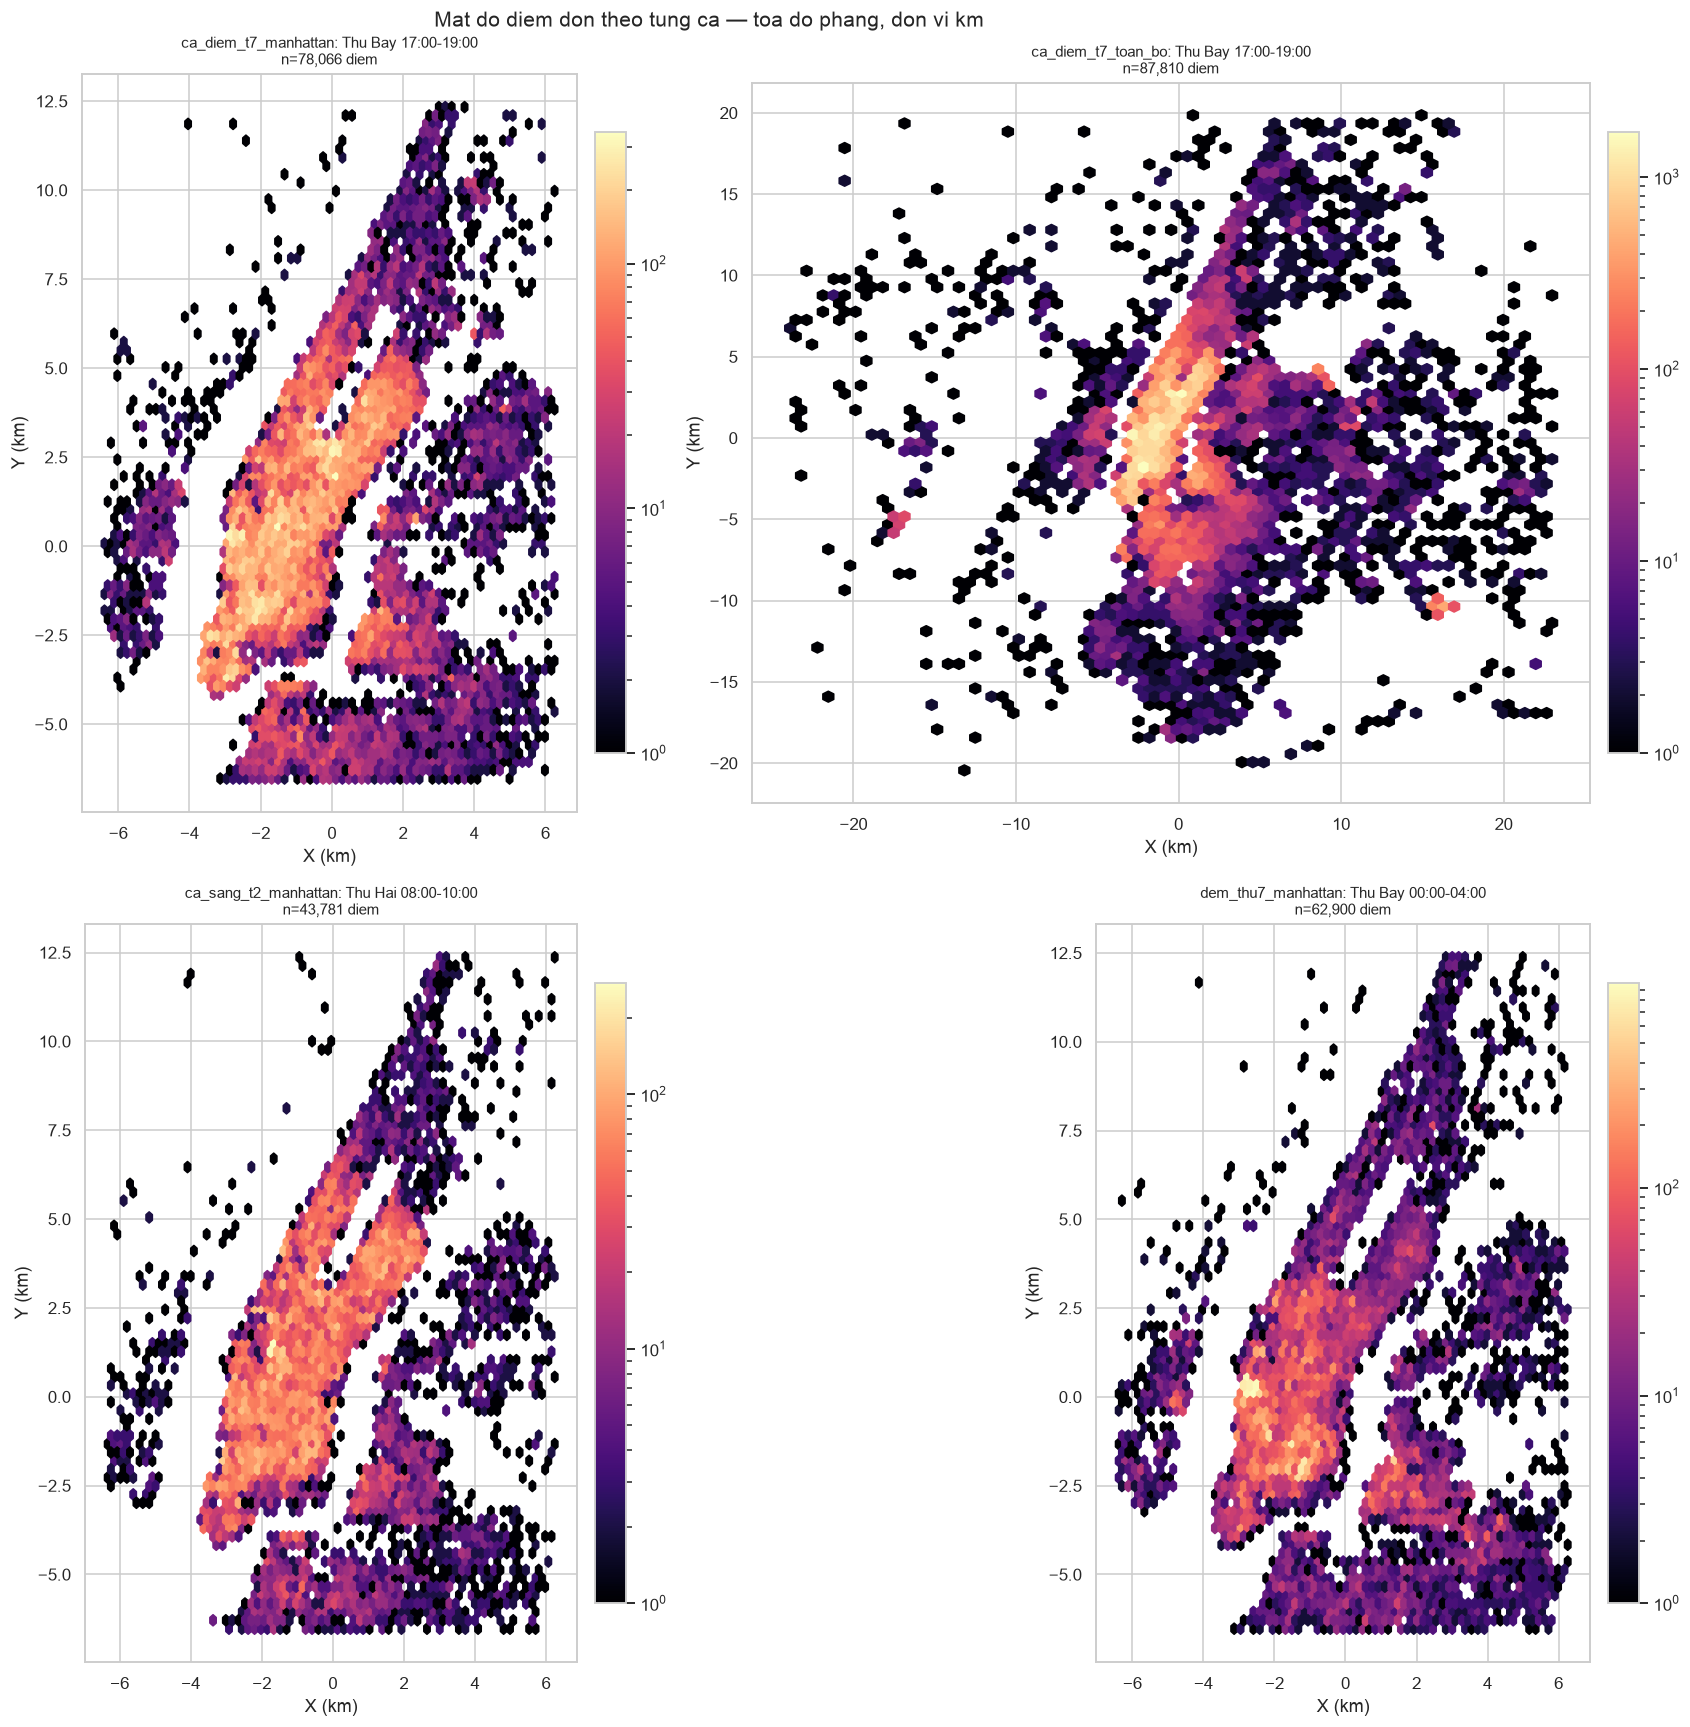

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(18, 16))
for ax, (name, res) in zip(axes.ravel(), zip(reports, results)):
    c = reports[name]["ket_qua"]
    xy = res.coords / 1000
    hb = ax.hexbin(xy[:, 0], xy[:, 1], gridsize=70, cmap="magma", mincnt=1, bins="log")
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(pp.SCENARIOS[name].describe() + f"\nn={len(res.points):,} diem", fontsize=10)
    ax.set_xlabel("X (km)")
    ax.set_ylabel("Y (km)")
    fig.colorbar(hb, ax=ax, fraction=0.035, pad=0.02)

plt.suptitle("Mat do diem don theo tung ca — toa do phang, don vi km", fontsize=14)
plt.tight_layout()
plt.savefig(OUT / "prep_03_scenarios.png", bbox_inches="tight")
plt.show()

---

## 4. Chốt `eps` và `MinPts` cho từng ca bằng k-distance

Đường cong k-distance: với mỗi điểm, sắp xếp khoảng cách tới các lân cận gần nhất rồi vẽ theo thứ tự. Chỗ đường cong **bẻ ngang** (elbow) là ngưỡng mà điểm bắt đầu thuộc về một cụm thật.

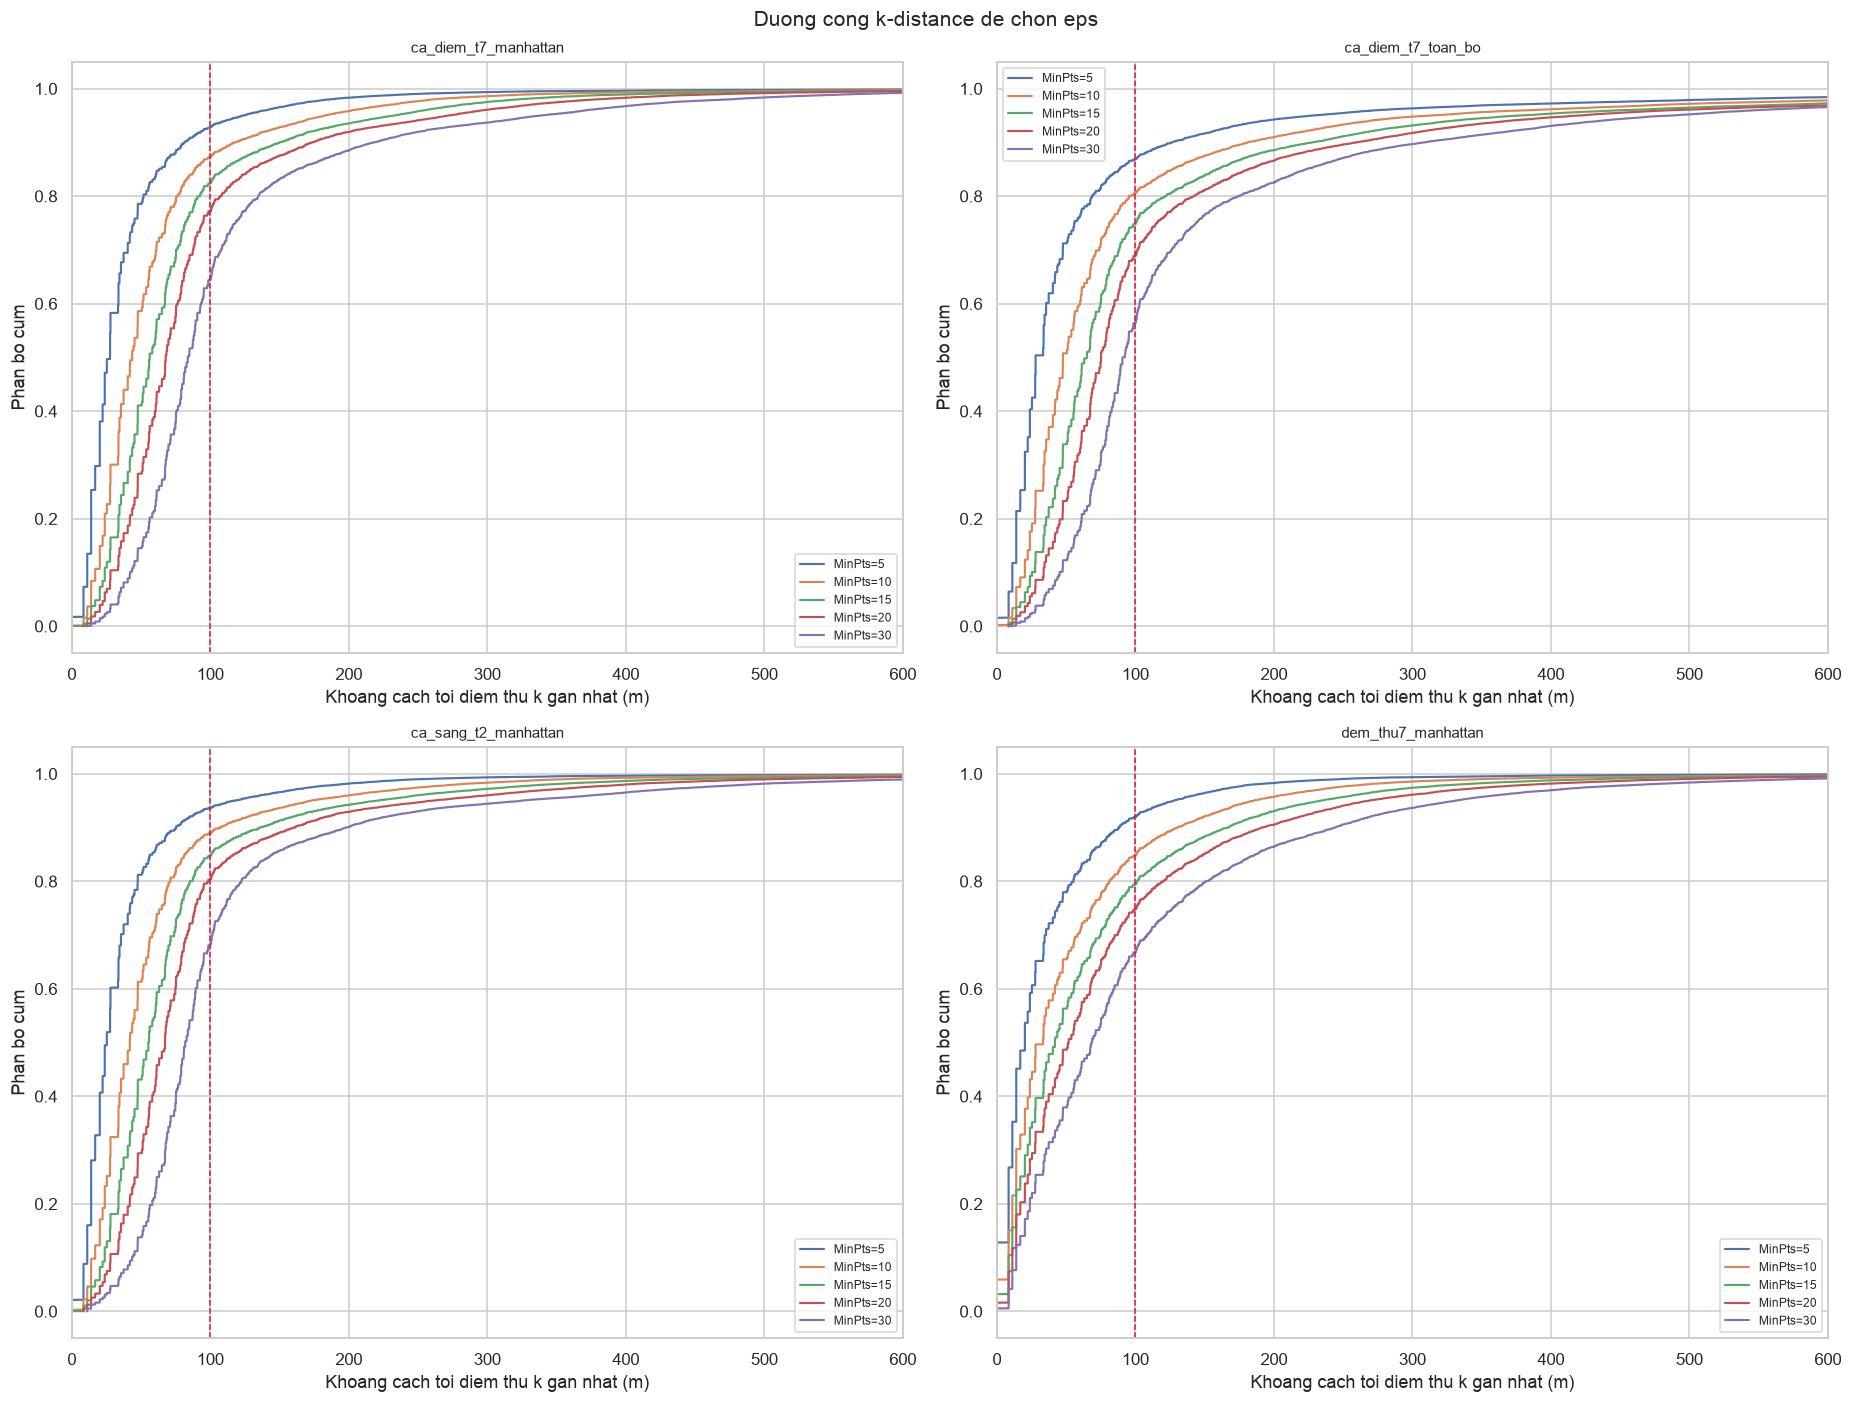

In [11]:
from sklearn.neighbors import NearestNeighbors

K_LIST = [5, 10, 15, 20, 30]
MAX_K = max(K_LIST)
SAMPLE = 40_000

kd = {}
for name, res in zip(reports, results):
    xy = res.coords
    rng = np.random.default_rng(pp.SCENARIOS[name].seed)
    sub = xy if len(xy) <= SAMPLE else xy[rng.choice(len(xy), SAMPLE, replace=False)]
    nn = NearestNeighbors(n_neighbors=MAX_K + 1, n_jobs=-1).fit(sub)
    d, _ = nn.kneighbors(sub)
    kd[name] = np.sort(d[:, 1:], axis=1)

fig, axes = plt.subplots(2, 2, figsize=(17, 13))
for ax, name in zip(axes.ravel(), reports):
    d = kd[name]
    for k in K_LIST:
        col = d[:, k - 1]
        col = col[col < 1500]
        ax.plot(np.sort(col), np.arange(1, len(col) + 1) / len(col), lw=1.4, label=f"MinPts={k}")
    ax.axvline(100, color="crimson", ls="--", lw=1)
    ax.set_xlim(0, 600)
    ax.set_xlabel("Khoang cach toi diem thu k gan nhat (m)")
    ax.set_ylabel("Phan bo cum")
    ax.set_title(pp.SCENARIOS[name].name, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle("Duong cong k-distance de chon eps", fontsize=14)
plt.tight_layout()
plt.savefig(OUT / "prep_04_kdistance.png", bbox_inches="tight")
plt.show()

In [12]:
rows = []
for name, d in kd.items():
    for eps_m in [50, 75, 100, 150, 200]:
        row = {"scenario": name, "eps_m": eps_m}
        for k in K_LIST:
            row[f"MinPts={k}"] = round((d[:, k - 1] <= eps_m).mean() * 100, 1)
        rows.append(row)

share = pd.DataFrame(rows)
for name in reports:
    print(f"\n{name}")
    print(share[share["scenario"] == name].drop(columns="scenario").to_string(index=False))

print("\nGia tri la % so diem co it nhat k ban trong ban kinh eps")


ca_diem_t7_manhattan
 eps_m  MinPts=5  MinPts=10  MinPts=15  MinPts=20  MinPts=30
    50      78.6       58.6       41.0       28.3       14.5
    75      88.1       79.0       68.5       57.5       37.8
   100      92.7       87.2       82.3       77.1       64.3
   150      96.5       92.7       89.9       87.4       83.0
   200      98.3       95.7       93.4       91.8       88.3

ca_diem_t7_toan_bo
 eps_m  MinPts=5  MinPts=10  MinPts=15  MinPts=20  MinPts=30
    50      70.9       50.3       33.5       23.0       12.0
    75      81.2       70.5       59.5       48.4       30.1
   100      86.5       79.8       74.0       67.9       55.2
   150      91.3       86.8       82.9       79.9       74.9
   200      93.9       90.2       87.6       85.3       80.8

ca_sang_t2_manhattan
 eps_m  MinPts=5  MinPts=10  MinPts=15  MinPts=20  MinPts=30
    50      81.2       61.3       43.1       29.4       13.7
    75      89.8       81.7       71.4       60.1       38.6
   100      93.6     

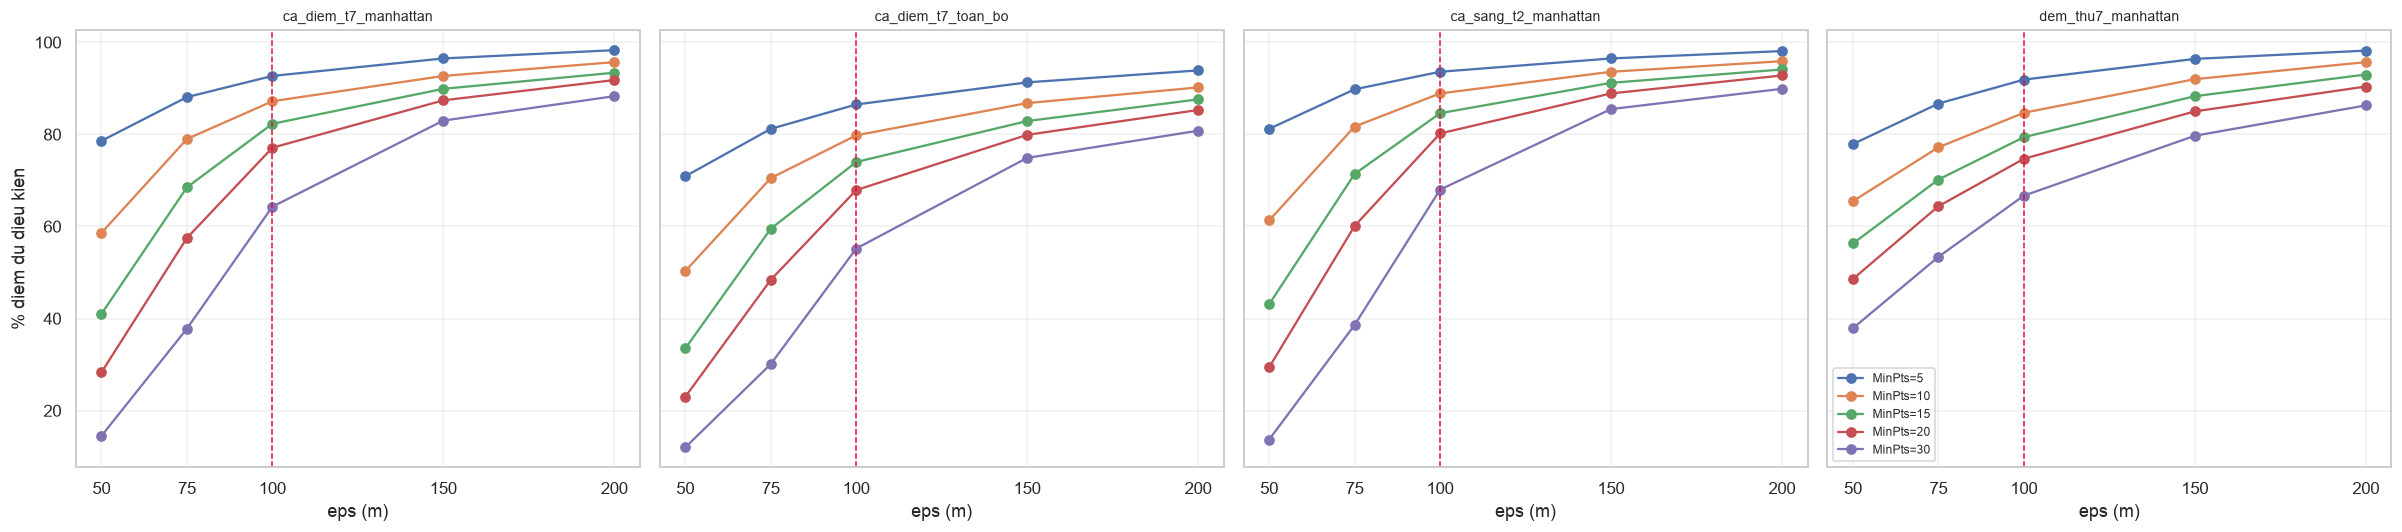

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5), sharey=True)
for ax, name in zip(axes, reports):
    sub = share[share["scenario"] == name]
    for col in [c for c in sub.columns if c.startswith("MinPts")]:
        ax.plot(sub["eps_m"], sub[col], marker="o", label=col)
    ax.axvline(100, color="crimson", ls="--", lw=1)
    ax.set_title(name, fontsize=9)
    ax.set_xlabel("eps (m)")
    ax.set_xticks([50, 75, 100, 150, 200])
    ax.grid(alpha=0.3)
axes[0].set_ylabel("% diem du dieu kien")
axes[-1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT / "prep_05_eps_sensitivity.png", bbox_inches="tight")
plt.show()

**Cách đọc bảng:** với `MinPts = 15`, `eps = 100 m`, nếu chỉ ~50–60% số điểm thoả điều kiện thì phần lớn dữ liệu sẽ thành **noise** — đúng tinh thần lọc nhiễu của DBSCAN. Nếu tỷ lệ này là 95% thì `eps` quá lớn, mọi chuyến lẻ cũng bị gộp vào một cụm khổng lồ và bài toán mất ý nghĩa.

---

## 5. Kiểm chứng đầu ra

Các assert ở đây là điều kiện để được chạy clustering. Nếu một cái fail thì dữ liệu đầu ra không đáng tin.

In [14]:
for name, res in zip(reports, results):
    dfp = res.points
    err = reports[name]["projection"]["loi_max_pct"]
    assert dfp["lat"].notna().all() and dfp["lon"].notna().all()
    assert dfp["x_m"].notna().all() and dfp["y_m"].notna().all()
    assert err < 0.001, f"{name}: phieu sai {err}%"
    assert dfp["hour"].between(0, 23).all()
    assert dfp["dow"].between(0, 6).all()
    print(
        f"{name:24s} n={len(dfp):>7,}  x=[{dfp['x_m'].min():9.0f},{dfp['x_m'].max():9.0f}]"
        f"  y=[{dfp['y_m'].min():9.0f},{dfp['y_m'].max():9.0f}]  loi={err:.6f}%"
    )

print("\nTat ca kich ban vuot qua kiem chung.")

ca_diem_t7_manhattan     n= 78,066  x=[    -6387,     6256]  y=[    -6526,    12333]  loi=0.000020%
ca_diem_t7_toan_bo       n= 87,810  x=[   -23887,    22978]  y=[   -20447,    19852]  loi=0.000118%
ca_sang_t2_manhattan     n= 43,781  x=[    -6335,     6244]  y=[    -6526,    12366]  loi=0.000039%
dem_thu7_manhattan       n= 62,900  x=[    -6385,     6257]  y=[    -6526,    12378]  loi=0.000030%

Tat ca kich ban vuot qua kiem chung.


In [15]:
import json

for name in reports:
    reports[name]["scenario"] = name

report_path = OUT / "preprocess_report.json"
report_path.write_text(json.dumps(reports, indent=2, ensure_ascii=False))
print("Bao cao QC:", report_path.relative_to(ROOT))
reports

Bao cao QC: outputs/preprocess_report.json


{'ca_diem_t7_manhattan': {'raw': {'dong': 4534327, 'files': ['*14.csv']},
  'toi_buoc_loc_toa_do': {'vao': 4534327,
   'ra': 4502417,
   'thieu_toa_do': 0,
   'toa_do_0_0': 0,
   'ngoai_bien_gioi': 31910,
   'bi_loai_tong': 31910},
  'cat_khung_gio_ngay_vung': {'vao': 4502417, 'ra': 78066},
  'lay_mau': {'vao': 78066, 'ra': 78066, 'n_yeu_cau': None},
  'projection': {'lat0': 40.738692760355164,
   'lon0': -73.97421728811436,
   'loi_max_pct': 1.983719469613275e-05,
   'loi_p99_pct': 8.419474040965646e-06,
   'n_cap_kiem_chung': 19971},
  'ket_qua': {'n_diem': 78066,
   'n_toa_do_lat_khac_nhau': 1616,
   'khoang_gio': [17, 19],
   'ngay_trong_tuan': [5],
   'bbox': [40.68, -74.05, 40.85, -73.9]},
  'scenario': 'ca_diem_t7_manhattan'},
 'ca_diem_t7_toan_bo': {'raw': {'dong': 4534327, 'files': ['*14.csv']},
  'toi_buoc_loc_toa_do': {'vao': 4534327,
   'ra': 4502417,
   'thieu_toa_do': 0,
   'toa_do_0_0': 0,
   'ngoai_bien_gioi': 31910,
   'bi_loai_tong': 31910},
  'cat_khung_gio_ngay_vung

---

## Kết luận

| Bước | Quyết định đã đưa ra | Căn cứ |
|---|---|---|
| Đọc | `float64` cho toạ độ | `float32` chỉ chính xác ~0.4 m ở NYC, sai số tương đối nhảy lên với cặp điểm gần nhau |
| Parse thời gian | `format="mixed"` | có dòng kèm giây (`:00`), format cứng sẽ crash |
| Lọc toạ độ | 3 nhóm: thiếu / `(0,0)` / ngoài bbox | 31.910 điểm rác tụ thành cụm giả nếu không loại |
| Chiếu toạ độ | azimuthal equidistant | sai số max 0.0001% vs 0.18% của equirectangular (đo thật ở trên) |
| Cắt khung giờ | theo ca × ngày × vùng | giảm 4.5M → 44–88k điểm, và phản ánh vận hành thật |
| Lấy mẫu | seed cố định 42 | kết quả lặp lại được, không “may mắn” |

### Bước tiếp theo

```pythonimport preprocess as ppfrom sklearn.cluster import DBSCAN
df = pp.load_processed("data/processed/ca_diem_t7_manhattan.csv")xy = df[["x_m", "y_m"]].to_numpy()          # don vi METlabels = DBSCAN(eps=100, min_samples=15).fit_predict(xy)```

1. Chạy DBSCAN với `eps ∈ {50, 100, 200 m}` × `MinPts ∈ {10, 15, 20}`, đo silhouette và tỷ lệ noise
2. Chuyển mỗi cụm thành đa giôn vùng đón
3. Xếp hạng hotspot theo **số chuyến / giờ**
4. So sánh với K-Means và KDE